# Importation des packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle 
import scipy.stats as st
import pandas as pd
from IPython.display import display
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from utils.cv_results import normalize_and_validate_cv_results, repair_repeated_leading_folds

# Nombre total d'œufs prédits

In [ ]:
# Une ligne de fichier de prédiction correspond à une instance d'œuf.
racine_projet = Path.cwd().parent if Path.cwd().name == "Resultats" else Path.cwd()
predictions_oeufs = {
    "U-Net œufs": (racine_projet / "UNet/masks/eval/UNet/oeufs", 0),
    "EggSegUNet": (racine_projet / "UNet/masks/eval/EggSegmentationHVUNet/oeufs", 0),
    "YOLO instance œufs": (racine_projet / "YOLO26/masks/eval/instance/oeufs", 0),
    "YOLO instance œufs classes": (racine_projet / "YOLO26/masks/eval/instance/oeufsclasses", 1),
}

def compter_oeufs_predits(dossier, classe_oeuf):
    if not dossier.is_dir():
        raise FileNotFoundError(f"Dossier de prédictions absent : {dossier}")
    return sum(
        int(float(ligne.split()[0])) == classe_oeuf
        for fichier in dossier.glob("pred_*.txt")
        for ligne in fichier.read_text().splitlines()
        if ligne.strip()
    )

nombre_oeufs_predits = pd.DataFrame.from_dict(
    {
        modele: compter_oeufs_predits(dossier, classe_oeuf)
        for modele, (dossier, classe_oeuf) in predictions_oeufs.items()
    },
    orient="index",
    columns=["Nombre total d'œufs prédits"],
).rename_axis("Modèle")
display(nombre_oeufs_predits)

# Images à exclure des résultats

In [7]:
# On retire ces données, car elles nécessitent un nouvel entrainement pour être correctement prises en compte (annotation ajoutée trop tard dans le jeu de données)
IMAGES_A_EXCLURE = [
     "0004860_14.22.53_362702_2020.jpg",
     "0004992_15.18.01_363346_2020.jpg",
     "0004993_15.18.07_363346_2020.jpg",
     "0004994_15.18.30_363346_2020.jpg",
     "0005022_17.09.00_363529_2020.jpg"
]

images_exclues_trouvees = set()


def filtrer_images_resultats(results, noms_images, nom_modele="Modèle"):
    """Retire des résultats CV toutes les images dont le nom est fourni."""
    noms_images = {Path(nom).name for nom in noms_images}
    if not noms_images:
        print(f"{nom_modele} : aucune image à exclure.")
        return results

    def filtrer_valeur(valeur, indices_a_garder, nombre_images):
        if isinstance(valeur, dict):
            return {
                cle: filtrer_valeur(sous_valeur, indices_a_garder, nombre_images)
                for cle, sous_valeur in valeur.items()
            }
        if isinstance(valeur, list) and len(valeur) == nombre_images:
            return [valeur[i] for i in indices_a_garder]
        if isinstance(valeur, tuple) and len(valeur) == nombre_images:
            return tuple(valeur[i] for i in indices_a_garder)
        if isinstance(valeur, np.ndarray) and len(valeur) == nombre_images:
            return valeur[indices_a_garder]
        return valeur

    resultats_filtres = {}
    images_retires = set()

    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            resultats_filtres[fold_name] = fold_results
            continue

        if isinstance(fold_results, list):  # Format YOLO
            fold_filtre = []
            for image_result in fold_results:
                nom_image = Path(image_result["image"]).name
                if nom_image in noms_images:
                    images_retires.add(nom_image)
                else:
                    fold_filtre.append(image_result)
            resultats_filtres[fold_name] = fold_filtre
        else:  # Formats U-Net et OpenUS
            noms_fold = [Path(nom).name for nom in fold_results["name"]]
            indices_a_garder = [i for i, nom in enumerate(noms_fold) if nom not in noms_images]
            images_retires.update(nom for nom in noms_fold if nom in noms_images)
            resultats_filtres[fold_name] = filtrer_valeur(
                fold_results, indices_a_garder, len(noms_fold)
            )

    images_exclues_trouvees.update(images_retires)
    print(f"{nom_modele} : {len(images_retires)} image(s) exclue(s).")
    return resultats_filtres

# Définition des fonctions

### Fonction pour agréger une métrique

In [8]:
def collect_metrics_all_folds(results, metric_name, class_name="Gonade"):
    dice = []
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            dice.extend(fold_results[metric_name][class_name])
        else:
            dice.extend(image_results["metrics"][class_name][metric_name] for image_results in fold_results)
    return dice

def collect_all_folds(results, name):
    categories = []
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            categories.extend(fold_results[name])
        else:
            categories.extend(image_results["metrics"][name] for image_results in fold_results)
    return categories

### Fonction pour visualiser et comparer des boxplots

In [9]:
def plot_boxplot(datasets, labels, colors, size=(6, 4), limite_echelle=np.arange(0, 1.01, 0.05)):
    n = len(datasets)
    fig, axes = plt.subplots(1, n, figsize=size)

    # Si un seul graphique, axes n'est pas une liste
    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):

        # Création du boxplot
        boxplot = ax.boxplot(datasets[i], patch_artist=True)

        # Labels
        ax.set_xticks(range(1, len(labels[i]) + 1))
        ax.set_xticklabels(labels[i])

        # Couleurs
        for patch, color in zip(boxplot["boxes"], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.4)
            patch.set_edgecolor(color)

        # Médianes
        for median in boxplot["medians"]:
            median.set_color("black")
            median.set_linewidth(1.5)

        # Grille
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")

        # Échelle
        ax.set_yticks(limite_echelle)
        ax.set_ylim(limite_echelle[0], limite_echelle[-1])

    plt.tight_layout()
    plt.show()


# Visualisation et comparaison des résultats des différents modèles : validation

## Importation des différents modèles

### U-NET models

In [10]:
# ======= CAVITE =======
# U-Net 2 classes
with open('../UNet/saves/Global/results_UNet_2classes.pkl', 'rb') as f:
    results_UNET_2classes = normalize_and_validate_cv_results(pickle.load(f))

# AttentionUNet++ 2 classes
with open('../UNet/saves/Global/results_AttentionUNet++_2classes.pkl', 'rb') as f:
    results_AttentionUNet_2classes = normalize_and_validate_cv_results(pickle.load(f))

# CSA-Net 2 classes
with open('../UNet/saves/Global/results_CSANet_3classes.pkl', 'rb') as f:
    results_CSANet_2classes = normalize_and_validate_cv_results(pickle.load(f))


# ======= OEUFS =======
# U-Net oeufs
with open('../UNet/saves/Global/results_UNet_oeufs.pkl', 'rb') as f:
    results_UNET_oeufs = normalize_and_validate_cv_results(pickle.load(f))
    
# EggSegUNet
with open('../UNet/saves/Global/results_EggSegmentationHVUNet_oeufs.pkl', 'rb') as f:
    results_SegHV_oeufs = normalize_and_validate_cv_results(pickle.load(f))

results_UNET_2classes = filtrer_images_resultats(results_UNET_2classes, IMAGES_A_EXCLURE, "U-Net 2 classes")
results_AttentionUNet_2classes = filtrer_images_resultats(results_AttentionUNet_2classes, IMAGES_A_EXCLURE, "Attention U-Net++ 2 classes")
results_CSANet_2classes = filtrer_images_resultats(results_CSANet_2classes, IMAGES_A_EXCLURE, "CSA-Net 2 classes")
results_UNET_oeufs = filtrer_images_resultats(results_UNET_oeufs, IMAGES_A_EXCLURE, "U-Net oeufs")
results_SegHV_oeufs = filtrer_images_resultats(results_SegHV_oeufs, IMAGES_A_EXCLURE, "EggSegUNet")

U-Net 2 classes : 5 image(s) exclue(s).
Attention U-Net++ 2 classes : 5 image(s) exclue(s).
CSA-Net 2 classes : 5 image(s) exclue(s).
U-Net oeufs : 0 image(s) exclue(s).
EggSegUNet : 0 image(s) exclue(s).


### YOLO models

In [11]:
# YOLO oeufs : réparation ciblée de l'ancien pickle à 7 folds, puis validation stricte.
with open('../YOLO26/saves/results_YOLO_instance_oeufs.pkl', 'rb') as fp:
    raw_yolo_oeufs = pickle.load(fp)
raw_yolo_oeufs, legacy_repaired = repair_repeated_leading_folds(raw_yolo_oeufs)
if legacy_repaired:
    print("Attention : deux copies historiques du fold 1 ont été ignorées dans les résultats YOLO œufs.")
results_YOLO_instance_oeufs = normalize_and_validate_cv_results(raw_yolo_oeufs)

# YOLO oeufs
with open('../YOLO26/saves/results_YOLO_instance_oeufsclasses.pkl', 'rb') as fp:
    results_YOLO_instance_oeufs2 = normalize_and_validate_cv_results(pickle.load(fp))

results_YOLO_instance_oeufs = filtrer_images_resultats(results_YOLO_instance_oeufs, IMAGES_A_EXCLURE, "YOLO instance oeufs")
results_YOLO_instance_oeufs2 = filtrer_images_resultats(results_YOLO_instance_oeufs2, IMAGES_A_EXCLURE, "YOLO instance oeufs classes")

Attention : deux copies historiques du fold 1 ont été ignorées dans les résultats YOLO œufs.
YOLO instance oeufs : 0 image(s) exclue(s).
YOLO instance oeufs classes : 0 image(s) exclue(s).


### OpenUS model

In [12]:
with open('../OpenUS-multiclass/OpenUS/output/custom_seg_cv5_2classes/results_OpenUS_2classes.pkl', 'rb') as fp:
    results_OpenUS_2classes = normalize_and_validate_cv_results(pickle.load(fp))

results_OpenUS_2classes = filtrer_images_resultats(results_OpenUS_2classes, IMAGES_A_EXCLURE, "OpenUS 2 classes")

images_exclues_absentes = {Path(nom).name for nom in IMAGES_A_EXCLURE} - images_exclues_trouvees
if images_exclues_absentes:
    print("Attention, image(s) absente(s) de tous les résultats :", sorted(images_exclues_absentes))

OpenUS 2 classes : 5 image(s) exclue(s).


### Moyenne et écart type des Dice par fold

In [25]:
def metrique_moyennes_par_fold(results, classe="Gonade", metric_name="dice_by_class"):
    moyennes = {}
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            valeurs = fold_results[metric_name][classe]
        else:
            valeurs = [image["metrics"][classe][metric_name] for image in fold_results]
        moyennes[fold_name] = np.nanmean(np.asarray(valeurs, dtype=float))
    return moyennes

modeles_dice = {
    "U-Net 2 classes": (results_UNET_2classes, "Gonade", "dice_by_class"),
    "Attention U-Net++ 2 classes": (results_AttentionUNet_2classes, "Gonade", "dice_by_class"),
    "CSA-Net 2 classes": (results_CSANet_2classes, "Gonade", "dice_by_class"),
    "OpenUS 2 classes": (results_OpenUS_2classes, "Gonade", "dice_by_class"),
    "U-Net œufs": (results_UNET_oeufs, "Oeuf", "dice_by_class"),
    "EggSegUNet": (results_SegHV_oeufs, "Oeuf", "dice_by_class"),
    "YOLO instance œufs": (results_YOLO_instance_oeufs, "Oeuf", "dice"),
    "YOLO instance œufs classes": (results_YOLO_instance_oeufs2, "Oeuf", "dice"),
}

for nom, (results, classe, metric_name) in modeles_dice.items():
    dice_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(dice_folds.values()), dtype=float)
    print(f"{nom} — Dice : moyenne = {np.mean(valeurs):.3f}, écart type = {np.std(valeurs):.3f}")
    print("  Dice moyen par fold :", {fold: round(valeur, 3) for fold, valeur in dice_folds.items()})

modeles_iou = {nom: (results, classe, "iou_by_class" if metric_name == "dice_by_class" else "iou")
               for nom, (results, classe, metric_name) in modeles_dice.items()}

for nom, (results, classe, metric_name) in modeles_iou.items():
    iou_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(iou_folds.values()), dtype=float)
    print(f"{nom} — IoU : moyenne = {np.mean(valeurs):.3f}, écart type = {np.std(valeurs):.3f}")
    print("  IoU moyen par fold :", {fold: round(valeur, 3) for fold, valeur in iou_folds.items()})

modeles_diff_surface = {
    "U-Net 2 classes": (results_UNET_2classes, "Gonade", "diff_surface"),
    "Attention U-Net++ 2 classes": (results_AttentionUNet_2classes, "Gonade", "diff_surface"),
    "CSA-Net 2 classes": (results_CSANet_2classes, "Gonade", "diff_surface"),
    "OpenUS 2 classes": (results_OpenUS_2classes, "Gonade", "diff_surface"),
    "U-Net œufs": (results_UNET_oeufs, "Oeuf", "diff_surface"),
    "EggSegUNet": (results_SegHV_oeufs, "Oeuf", "diff_surface"),
    "YOLO instance œufs": (results_YOLO_instance_oeufs, "Oeuf", "diff_surface"),
}

for nom, (results, classe, metric_name) in modeles_diff_surface.items():
    diff_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(diff_folds.values()), dtype=float)
    print(f"{nom} — Différence absolue de surface médiane : moyenne = {np.nanmean(valeurs):.3f}, écart type = {np.nanstd(valeurs):.3f}")
    print("  Différence absolue de surface médiane par fold :")
    for fold, valeur in diff_folds.items():
        fold_results = results[fold]
        if isinstance(fold_results, dict):
            fold_values = fold_results[metric_name][classe]
        else:
            fold_values = [image["metrics"][classe][metric_name] for image in fold_results]
        fold_values = np.asarray(fold_values, dtype=float)
        print(f"    {fold}: {valeur:.3f} mm² ({np.isfinite(fold_values).sum()}/{len(fold_values)} valeurs finies)")

# Precision
modeles_precision = {
    "U-Net 2 classes": (results_UNET_2classes, "Gonade", "precision_by_class"),
    "Attention U-Net++ 2 classes": (results_AttentionUNet_2classes, "Gonade", "precision_by_class"),
    "CSA-Net 2 classes": (results_CSANet_2classes, "Gonade", "precision_by_class"),
    "OpenUS 2 classes": (results_OpenUS_2classes, "Gonade", "precision_by_class"),
    "U-Net œufs": (results_UNET_oeufs, "Oeuf", "precision_by_class"),
    "EggSegUNet": ( results_SegHV_oeufs, "Oeuf", "precision_by_class"),
    "YOLO instance œufs": (results_YOLO_instance_oeufs, "Oeuf", "precision"),
    "YOLO instance œufs classes": (results_YOLO_instance_oeufs2, "Oeuf", "precision"),
}  

for nom, (results, classe, metric_name) in modeles_precision.items():
    precision_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(precision_folds.values()), dtype=float)
    print(f"{nom} — Précision : moyenne = {np.mean(valeurs):.3f}, écart type = {np.std(valeurs):.3f}")
    print("  Précision moyenne par fold :", {fold: round(valeur, 3) for fold, valeur in precision_folds.items()})

modeles_recall = {
    "U-Net 2 classes": (results_UNET_2classes, "Gonade", "recall_by_class"),
    "Attention U-Net++ 2 classes": (results_AttentionUNet_2classes, "Gonade", "recall_by_class"),
    "CSA-Net 2 classes": (results_CSANet_2classes, "Gonade", "recall_by_class"),
    "OpenUS 2 classes": (results_OpenUS_2classes, "Gonade", "recall_by_class"),
    "U-Net œufs": (results_UNET_oeufs, "Oeuf", "recall_by_class"),
    "EggSegUNet": (results_SegHV_oeufs, "Oeuf", "recall_by_class"),
    "YOLO instance œufs": (results_YOLO_instance_oeufs, "Oeuf", "recall"),
    "YOLO instance œufs classes": (results_YOLO_instance_oeufs2, "Oeuf", "recall"),
}   

for nom, (results, classe, metric_name) in modeles_recall.items():
    recall_folds = metrique_moyennes_par_fold(results, classe, metric_name)
    valeurs = np.asarray(list(recall_folds.values()), dtype=float)
    print(f"{nom} — Rappel : moyenne = {np.mean(valeurs):.3f}, écart type = {np.std(valeurs):.3f}")
    print("  Rappel moyen par fold :", {fold: round(valeur, 3) for fold, valeur in recall_folds.items()})  

U-Net 2 classes — Dice : moyenne = 0.793, écart type = 0.054
  Dice moyen par fold : {'fold_1': np.float64(0.845), 'fold_2': np.float64(0.815), 'fold_3': np.float64(0.72), 'fold_4': np.float64(0.739), 'fold_5': np.float64(0.849)}
Attention U-Net++ 2 classes — Dice : moyenne = 0.795, écart type = 0.047
  Dice moyen par fold : {'fold_1': np.float64(0.815), 'fold_2': np.float64(0.815), 'fold_3': np.float64(0.733), 'fold_4': np.float64(0.749), 'fold_5': np.float64(0.861)}
CSA-Net 2 classes — Dice : moyenne = 0.731, écart type = 0.056
  Dice moyen par fold : {'fold_1': np.float64(0.732), 'fold_2': np.float64(0.794), 'fold_3': np.float64(0.653), 'fold_4': np.float64(0.685), 'fold_5': np.float64(0.791)}
OpenUS 2 classes — Dice : moyenne = 0.794, écart type = 0.036
  Dice moyen par fold : {'fold_1': np.float64(0.768), 'fold_2': np.float64(0.739), 'fold_3': np.float64(0.822), 'fold_4': np.float64(0.806), 'fold_5': np.float64(0.834)}
U-Net œufs — Dice : moyenne = 0.377, écart type = 0.090
  Dice

## Comparaisons globales des modèles

In [14]:
names_gonade = collect_all_folds(results_UNET_2classes, "name")
names_oeufs = collect_all_folds(results_UNET_oeufs, "name")
names_gonade_OpenUS = collect_all_folds(results_OpenUS_2classes, "name")

### Récupération des temps d'entrainement moyens - des IOU - Diff surfaces

In [15]:
# -------- Temps d'exécution des modèles --------
print("\n-------------- Time --------------\n")
print(f"UNet 2 classes: {np.sum([results_UNET_2classes[fold]["time"] for fold in results_UNET_2classes])/60:.2f} minutes")
print(f"Attention UNet++ 2 classes: {np.sum([results_AttentionUNet_2classes[fold]["time"] for fold in results_AttentionUNet_2classes])/60:.2f} minutes")
print(f"CSA-Net 2 classes: {np.sum([results_CSANet_2classes[fold]["time"] for fold in results_CSANet_2classes])/60:.2f} minutes")
print(f"UNet oeufs: {np.sum([results_UNET_oeufs[fold]["time"] for fold in results_UNET_oeufs])/60:.2f} minutes")
print(f"SegHVUNet: {np.sum([results_SegHV_oeufs[fold]["time"] for fold in results_SegHV_oeufs])/60:.2f} minutes")

# -------- IOU --------
print("\n-------------- IoU --------------\n")
print(f"IoU moyen U-NEt 2 classes : {np.mean(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")
print(f"IoU moyen Attention U-NEt 2 classes : {np.mean(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")
print(f"IoU moyen CSA-Net 2 classes : {np.mean(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")  
print(f"IoU moyen OpenUS 2 classes : {np.mean(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f} (std : {np.std(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="iou_by_class")):.3f})")

# -------- Diff surface --------
print("\n-------------- Différence de surface (en cm2) --------------\n")
print(f"Diff surface moyen U-NEt 2 classes : {np.nanmean(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen Attention U-NEt 2 classes : {np.nanmean(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen CSA-Net 2 classes : {np.nanmean(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen OpenUS 2 classes : {np.nanmean(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen U-NEt oeufs : {np.nanmean(collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="diff_surface")):.3f})")
print(f"Diff surface moyen SegHVUNet : {np.nanmean(collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="diff_surface")):.3f} (std : {np.nanstd(collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="diff_surface")):.3f})")


-------------- Time --------------

UNet 2 classes: 22.15 minutes
Attention UNet++ 2 classes: 16.39 minutes
CSA-Net 2 classes: 54.19 minutes
UNet oeufs: 19.44 minutes
SegHVUNet: 22.72 minutes

-------------- IoU --------------

IoU moyen U-NEt 2 classes : 0.690 (std : 0.204)
IoU moyen Attention U-NEt 2 classes : 0.689 (std : 0.195)
IoU moyen CSA-Net 2 classes : 0.610 (std : 0.209)
IoU moyen OpenUS 2 classes : 0.687 (std : 0.204)

-------------- Différence de surface (en cm2) --------------

Diff surface moyen U-NEt 2 classes : 0.181 (std : 0.177)
Diff surface moyen Attention U-NEt 2 classes : 0.199 (std : 0.207)
Diff surface moyen CSA-Net 2 classes : 0.158 (std : 0.151)
Diff surface moyen OpenUS 2 classes : 0.247 (std : 0.306)
Diff surface moyen U-NEt oeufs : 2.058 (std : 2.057)
Diff surface moyen SegHVUNet : 2.116 (std : 1.567)


### Récupération des Dice

In [16]:
# Cavite
DICE_UNET_2classes_Gonade = collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_ATTENTION_UNET_2classes_Gonade = collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_CSANet_2classes_Gonade = collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="dice_by_class")
DICE_OpenUS_2classes_Gonade = collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="dice_by_class")

# Oeufs
DICE_UNET_oeufs = collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="dice_by_class")
DICE_SegHV_oeufs = collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="dice_by_class")
DICE_YOLO_instance_oeufs = collect_metrics_all_folds(results_YOLO_instance_oeufs, class_name="Oeuf", metric_name="dice")
DICE_YOLO_instance_oeufs2 = collect_metrics_all_folds(results_YOLO_instance_oeufs2, class_name="Oeuf", metric_name="dice")

### Récupération de la différence de surface

In [17]:
# Cavite
Diff_UNET_2classes = collect_metrics_all_folds(results_UNET_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_ATTENTION_UNET_2classes = collect_metrics_all_folds(results_AttentionUNet_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_CSANet_2classes = collect_metrics_all_folds(results_CSANet_2classes, class_name="Gonade", metric_name="diff_surface")
Diff_OpenUS_2classes = collect_metrics_all_folds(results_OpenUS_2classes, class_name="Gonade", metric_name="diff_surface")

# oeufs
Diff_UNET_oeufs = collect_metrics_all_folds(results_UNET_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_SegHV_oeufs = collect_metrics_all_folds(results_SegHV_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_YOLO_instance_oeufs = collect_metrics_all_folds(results_YOLO_instance_oeufs, class_name="Oeuf", metric_name="diff_surface")
Diff_YOLO_instance_oeufs2 = collect_metrics_all_folds(results_YOLO_instance_oeufs2, class_name="Oeuf", metric_name="diff_surface")

### Boxplots Dice des gonades

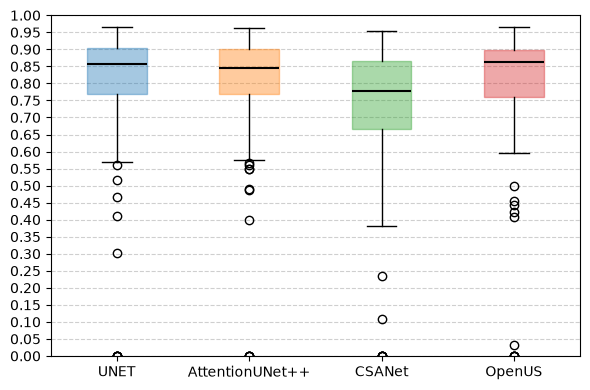

In [18]:
data = [DICE_UNET_2classes_Gonade, DICE_ATTENTION_UNET_2classes_Gonade, DICE_CSANet_2classes_Gonade, DICE_OpenUS_2classes_Gonade]
labels = ["UNET", "AttentionUNet++", "CSANet", "OpenUS"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.00, 1.01, 0.05)
plot_boxplot([data], [labels], colors, size=(6, 4), limite_echelle=limite)

In [19]:
# ------- Comparaison des moyennes ----
print(f"Dice moyen U-NEt 2 classes : {np.mean(DICE_UNET_2classes_Gonade):.3f} (std : {np.std(DICE_UNET_2classes_Gonade):.3f})")
print(f"Dice moyen Attention U-NEt 2 classes : {np.mean(DICE_ATTENTION_UNET_2classes_Gonade):.3f} (std : {np.std(DICE_ATTENTION_UNET_2classes_Gonade):.3f})")
print(f"Dice moyen CSA-Net 2 classes : {np.mean(DICE_CSANet_2classes_Gonade):.3f} (std : {np.std(DICE_CSANet_2classes_Gonade):.3f})")
print(f"Dice moyen OpenUS 2 classes : {np.mean(DICE_OpenUS_2classes_Gonade):.3f} (std : {np.std(DICE_OpenUS_2classes_Gonade):.3f})")

Dice moyen U-NEt 2 classes : 0.793 (std : 0.201)
Dice moyen Attention U-NEt 2 classes : 0.795 (std : 0.188)
Dice moyen CSA-Net 2 classes : 0.731 (std : 0.208)
Dice moyen OpenUS 2 classes : 0.791 (std : 0.200)


In [20]:
# -------------- Analyse outliers --------------------
# Récupère les images avec un DICE entre inf et sup
inf= 0.9
sup = 1.1

# UNET
indices = [i for i,x in enumerate(DICE_UNET_2classes_Gonade) if x < sup and x > inf]
print(f"Dice UNet :{[DICE_UNET_2classes_Gonade[indice] for indice in indices]}")
print(f"Names UNet : {[names_gonade[indice] for indice in indices]}")
print("----------------------------------------------------------------")

# UNET++
indices = [i for i,x in enumerate(DICE_ATTENTION_UNET_2classes_Gonade) if x < sup and x > inf]
print(f"Dice UNet++ :{[DICE_ATTENTION_UNET_2classes_Gonade[indice] for indice in indices]}")
print(f"Names Unet ++ : {[names_gonade[indice] for indice in indices]}")
print("----------------------------------------------------------------")

# CSANET
indices = [i for i,x in enumerate(DICE_CSANet_2classes_Gonade) if x < sup and x > inf]
print(f"Dice CSANet :{[DICE_CSANet_2classes_Gonade[indice] for indice in indices]}")
print(f"Names CSANet : {[names_gonade[indice] for indice in indices]}")
print("----------------------------------------------------------------")

# OPENUS
indices = [i for i,x in enumerate(DICE_OpenUS_2classes_Gonade) if x < sup and x > inf]
print(f"Dice OPENUS :{[DICE_OpenUS_2classes_Gonade[indice] for indice in indices]}")
print(f"Names OPENUS : {[names_gonade_OpenUS[indice] for indice in indices]}")
print("----------------------------------------------------------------")

Dice UNet :[0.9080236554145813, 0.9260372519493103, 0.9190778136253357, 0.9077939987182617, 0.9324748516082764, 0.9531981348991394, 0.9465711116790771, 0.9023623466491699, 0.9061283469200134, 0.9511811137199402, 0.9516494870185852, 0.9503526091575623, 0.9478006958961487, 0.9314644932746887, 0.9274132251739502, 0.9064183831214905, 0.9646077156066895, 0.9374154210090637, 0.9003683924674988, 0.9048002362251282, 0.9223153591156006, 0.9128578901290894, 0.921421229839325, 0.9035928845405579, 0.901357889175415, 0.930915892124176, 0.9145143032073975, 0.917655348777771, 0.9113913774490356, 0.9430245757102966, 0.9276823401451111, 0.9346849918365479, 0.9431267380714417, 0.9400681853294373, 0.9020461440086365, 0.905751645565033, 0.9205169081687927, 0.9116433262825012, 0.9138861894607544, 0.907341718673706]
Names UNet : ['0004672_12.18.23_356948_2019.jpg', '0004673_12.18.32_356948_2019.jpg', '0004674_12.18.40_356948_2019.jpg', '0004675_12.18.49_356948_2019.jpg', '0004862_14.23.23_362702_2020.jpg', 

## Analyse par images

Cette section compare, pour une image donnée, les métriques de segmentation de la gonade obtenues par les différents modèles 3 classes.

In [21]:
def extraire_metriques_image(results, nom_image, classe="Gonade"):
    """Extrait les métriques d'une image depuis des résultats U-Net ou YOLO."""
    nom_recherche = Path(nom_image).name

    for fold_results in results.values():
        # Format U-Net : un dictionnaire de listes par fold
        if isinstance(fold_results, dict):
            noms = fold_results.get("name", [])
            for index, nom in enumerate(noms):
                if Path(nom).name == nom_recherche:
                    return {
                        "Dice": fold_results["dice_by_class"][classe][index],
                        "IoU": fold_results["iou_by_class"][classe][index],
                        "Précision": fold_results["precision_by_class"][classe][index],
                        "Rappel": fold_results["recall_by_class"][classe][index],
                        "Différence de surface": (fold_results.get("diff_surface", fold_results.get("diff_surf")))[classe][index],
                    }

        # Format YOLO : une liste de résultats individuels par fold
        else:
            for image_results in fold_results:
                if Path(image_results["image"]).name == nom_recherche:
                    metriques = image_results["metrics"][classe]
                    return {
                        "Dice": metriques["dice"],
                        "IoU": metriques["iou"],
                        "Précision": metriques["precision"],
                        "Rappel": metriques["recall"],
                        "Différence de surface": metriques["diff_surface"],
                    }

    raise ValueError(
        f"L'image '{nom_image}' est introuvable dans les résultats de ce modèle. "
        f"Utilisez le nom d'une image du jeu de validation 2 classes."
    )


def comparer_modeles_pour_image(nom_image, classe="Gonade"):
    modeles = {
        "U-Net": results_UNET_2classes,
        "Attention U-Net++": results_AttentionUNet_2classes,
        "OpenUS": results_OpenUS_2classes,
        "CSA-Net": results_CSANet_2classes,
    }

    lignes = {
        nom_modele: extraire_metriques_image(resultats, nom_image, classe)
        for nom_modele, resultats in modeles.items()
    }

    tableau = pd.DataFrame.from_dict(lignes, orient="index").rename_axis("Modèle").round(3)
    return tableau.sort_values("Dice", ascending=False)


def lister_images_resultats(results):
    """Retourne les noms des images présentes dans tous les folds d'un modèle."""
    noms = set()
    for fold_name, fold_results in results.items():
        if fold_name == "fold_times":
            continue
        if isinstance(fold_results, dict):
            noms.update(Path(nom).name for nom in fold_results.get("name", []))
        else:
            noms.update(Path(image_results["image"]).name for image_results in fold_results)
    return noms


MODELES_OEUFS = {
    "U-Net": results_UNET_oeufs,
    "EggSegUNet": results_SegHV_oeufs,
    "YOLO instance œufs": results_YOLO_instance_oeufs,
    "YOLO instance œufs classes": results_YOLO_instance_oeufs2,
}

images_oeufs_disponibles = sorted(
    set.intersection(*(lister_images_resultats(resultats) for resultats in MODELES_OEUFS.values()))
)


def analyser_image_oeufs(nom_image):
    """Affiche les métriques et la visualisation comparative d'une image d'œufs."""
    nom_recherche = Path(nom_image).name
    if nom_recherche not in images_oeufs_disponibles:
        exemples = ", ".join(images_oeufs_disponibles[:5])
        raise ValueError(
            f"L'image '{nom_image}' n'est pas disponible pour les quatre modèles d'œufs. "
            f"Choisissez un nom dans `images_oeufs_disponibles` (par exemple : {exemples})."
        )

    lignes = {
        nom_modele: extraire_metriques_image(resultats, nom_recherche, classe="Oeuf")
        for nom_modele, resultats in MODELES_OEUFS.items()
    }
    tableau = (
        pd.DataFrame.from_dict(lignes, orient="index")
        .rename_axis("Modèle")
        .round(3)
        .sort_values("Dice", ascending=False)
    )
    display(tableau)

    visualisation_path = Path("visualisation") / "oeufs" / f"combined_{Path(nom_recherche).stem}.png"
    if not visualisation_path.exists():
        raise FileNotFoundError(
            f"Visualisation absente pour '{nom_recherche}' : {visualisation_path}"
        )

    image = plt.imread(visualisation_path)
    plt.figure(figsize=(18, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Comparaison des segmentations — {nom_recherche}")
    plt.tight_layout()
    plt.show()
    return tableau

### Sélection d'une image d'une cavité

Modifier la valeur de `nom_image`, puis exécuter la cellule pour afficher la comparaison.

In [18]:
nom_image = "0006263_14.45.50_406915_2022.jpg"
comparer_modeles_pour_image(nom_image)

,Dice,IoU,Précision,Rappel,Différence de surface
Modèle,,,,,
U-Net,0.892,0.805,0.930,0.857,0.065
OpenUS,0.827,0.705,0.853,0.803,0.049
Attention U-Net++,0.738,0.585,0.666,0.828,0.199
CSA-Net,0.644,0.475,0.521,0.844,0.281


### Sélection d'une image d'œufs

,Dice,IoU,Précision,Rappel,Différence de surface
Modèle,,,,,
U-Net,0.708,0.548,0.725,0.693,0.82
YOLO instance œufs,0.651,0.482,0.650,0.651,1.87
EggSegUNet,0.637,0.467,0.603,0.674,1.08
YOLO instance œufs classes,0.602,0.431,0.663,0.551,0.61


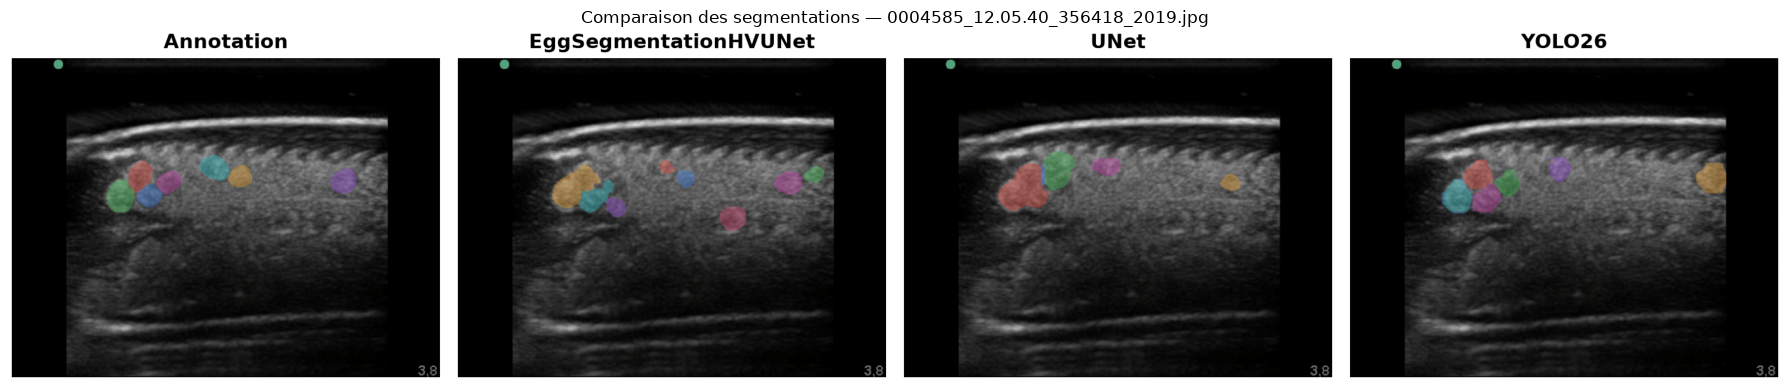

In [23]:
nom_image_oeufs = "0004585_12.05.40_356418_2019.jpg"
analyse_oeufs = analyser_image_oeufs(nom_image_oeufs)

### Boxplots Dice des oeufs

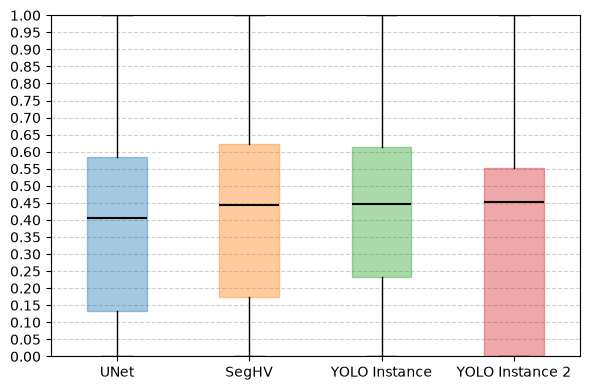

In [ ]:
data = [DICE_UNET_oeufs, DICE_SegHV_oeufs, DICE_YOLO_instance_oeufs, DICE_YOLO_instance_oeufs2]
labels = ["UNet", "SegHVuNet", "YOLO Instance", "YOLO Instance 2"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0.00, 1.01, 0.05)
plot_boxplot([data], [labels], colors, size=(6, 4), limite_echelle=limite)

In [24]:
# --- Comparaison des moyennes pour les oeufs ---
print(f"Dice moyen U-NEt : {np.mean(DICE_UNET_oeufs):.3f} (std : {np.std(DICE_UNET_oeufs):.3f})")
print(f"Dice moyen SegHV : {np.mean(DICE_SegHV_oeufs):.3f} (std : {np.std(DICE_SegHV_oeufs):.3f})")
print(f"Dice moyen YOLO instance : {np.mean(DICE_YOLO_instance_oeufs):.3f} (std : {np.std(DICE_YOLO_instance_oeufs):.3f})")

Dice moyen U-NEt : 0.371 (std : 0.257)
Dice moyen SegHV : 0.403 (std : 0.264)
Dice moyen YOLO instance : 0.411 (std : 0.263)


### Boxplots Diff surface des gonades

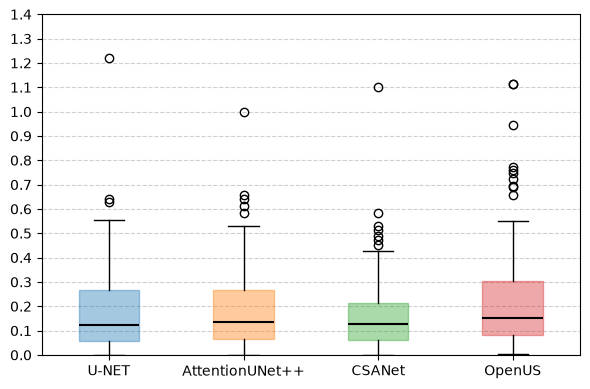

In [25]:
data = [
    Diff_UNET_2classes,
    Diff_ATTENTION_UNET_2classes,
    Diff_CSANet_2classes,
    Diff_OpenUS_2classes
]

data_clean = []

for x in data:
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]  # enlève NaN et inf
    data_clean.append(x)

labels = ["U-NET", "AttentionUNet++", "CSANet", "OpenUS"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0, 1.5, 0.1)
plot_boxplot([data_clean], [labels], colors, size=(6, 4), limite_echelle=limite)

### Différence absolue de surface médiane d'un œuf : prédiction vs annotation (mm²)

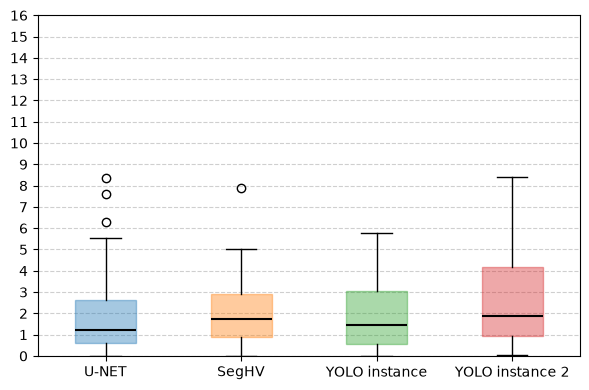

In [26]:
data = [
    Diff_UNET_oeufs,
    Diff_SegHV_oeufs,
    Diff_YOLO_instance_oeufs,
    Diff_YOLO_instance_oeufs2
]

data_clean = []

for x in data:
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x)]  # enlève NaN et inf
    data_clean.append(x)

labels = ["U-NET",  "SegHV", "YOLO instance", "YOLO instance 2"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d629c1", "#121b82"]  # Bleu, Orange, Vert, Rouge
limite = np.arange(0, 17, 1)
plot_boxplot([data_clean], [labels], colors, size=(6, 4), limite_echelle=limite)

## Résultats d'un modèle spécifique

### Sélection du modèle

In [27]:
modele = results_UNET_2classes
Dice_results = DICE_UNET_2classes_Gonade

### Récupération des catégories

In [28]:
categories = collect_all_folds(modele, "category")
positions = collect_all_folds(modele, "ops")
positions_ratio = collect_all_folds(modele, "ops_ratio")
diff_surfaces = collect_all_folds(modele, "diff_surface")

### Boxplots Dice selon les catégories

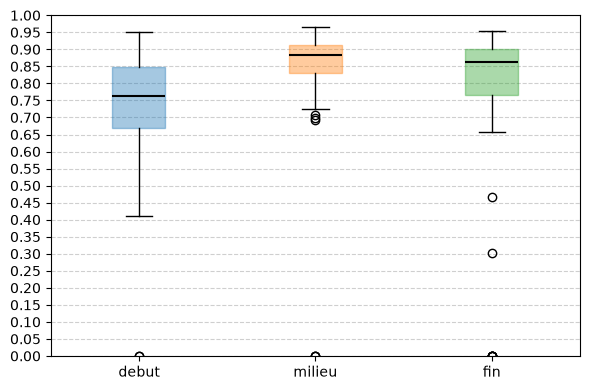

In [29]:
dice_by_category = {}

for category, dice in zip(categories, Dice_results):
    if category not in dice_by_category:
        dice_by_category[category] = []

    dice_by_category[category].append(dice)

labels = list(dice_by_category.keys())
data = [dice_by_category[category] for category in labels]

plot_boxplot(
    datasets=[data],
    labels=[labels],
    size = (6,4),
    colors=["#1f77b4", "#ff7f0e", "#2ca02c" ]
)

In [80]:
# Test de comparaison des moyennes par catégorie
print(st.ttest_ind(data[0], data[2], equal_var=False))

# Test de l'ANOVA
print(st.f_oneway(data[0], data[1], data[2])) #Significatif à 5%

TtestResult(statistic=np.float64(-0.10816923001584985), pvalue=np.float64(0.914142169754535), df=np.float64(77.180083205795))
F_onewayResult(statistic=np.float64(3.0903107382951776), pvalue=np.float64(0.04856039448978857))


### Boxplots Dice selon les positions

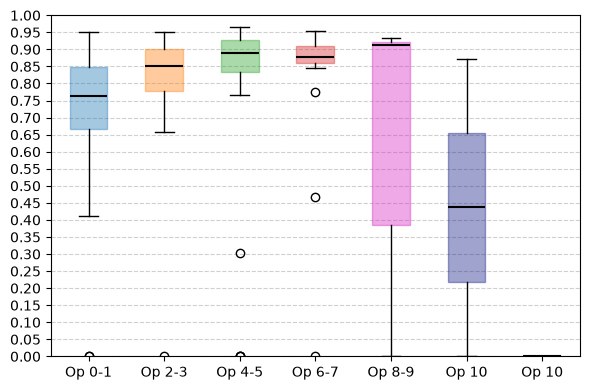

In [81]:
dice_by_position = {}

for position, dice in zip(positions, Dice_results):

    # Regroupement par paires : 0-1, 2-3, 4-5, ...
    group_start = (position // 2) * 2

    if group_start not in dice_by_position:
        dice_by_position[group_start] = []

    dice_by_position[group_start].append(dice)

labels = sorted(dice_by_position.keys())

display_labels = [
    f"Op {position}-{position + 1}" if position < 10 else "Op 10"
    for position in labels
]

data = [dice_by_position[position] for position in labels]

plot_boxplot(
    datasets=[data],
    labels=[display_labels],
    size=(6, 4),
    colors=[
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#d629c1", "#121b82"
    ]
)

### Boxplots Dice selon les positions ratios

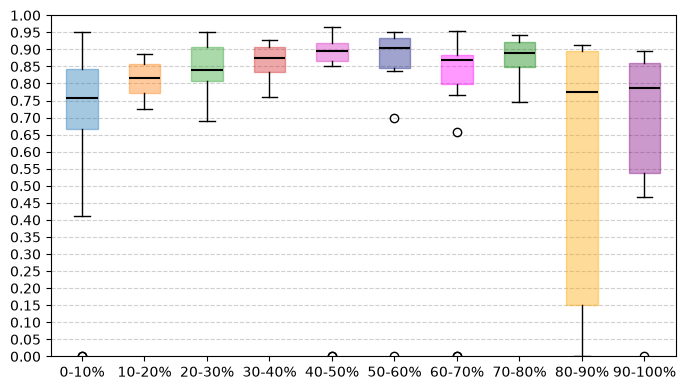

In [82]:
dice_by_position_ratio = {}

for position_ratio, dice in zip(positions_ratio, Dice_results):

    # Regroupement par tranches de 10 %
    group_start = min(int(position_ratio * 10), 9) * 10

    if group_start not in dice_by_position_ratio:
        dice_by_position_ratio[group_start] = []

    dice_by_position_ratio[group_start].append(dice)

labels = sorted(dice_by_position_ratio.keys())

display_labels = [
    f"{position}-{position + 10}%"
    for position in labels
]

data = [dice_by_position_ratio[position] for position in labels]

plot_boxplot(
    datasets=[data],
    labels=[display_labels],
    size=(7, 4),
    colors=[
        "#1f77b4", "#ff7f0e", "#2ca02c",
        "#d62728", "#d629c1", "#121b82",
        "#ff00ff", "green", "orange", "purple"
    ]
)

# Résultats sur l'échantillon de test